# MLForecast with synthetic data

This guide compares an observed-data baseline, global training with observed and augmented series, and a model trained only on independent synthetic series and transferred zero-shot to the observed series.

We use the classic [Box–Jenkins airline passenger series](https://search.r-project.org/R/refmans/datasets/html/AirPassengers.html), holding out its final 12 months before generating any augmented data.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mlforecast import MLForecast
from sklearn.linear_model import Ridge

from synforecast import SynAugment, generate_series

In [ ]:
HORIZON = 12
TARGET_ID = "AirPassengers"
data_path = Path("nbs/data/air_passengers.csv")
if not data_path.exists():
    data_path = Path("../../data/air_passengers.csv")

observed_df = pd.read_csv(data_path, parse_dates=["ds"])
train_df = observed_df.iloc[:-HORIZON].copy()
test_df = observed_df.iloc[-HORIZON:].copy()
train_df.tail()

,unique_id,ds,y
127,AirPassengers,1959-08-31,559.0
128,AirPassengers,1959-09-30,463.0
129,AirPassengers,1959-10-31,407.0
130,AirPassengers,1959-11-30,362.0
131,AirPassengers,1959-12-31,405.0


In [ ]:
augmented_train_df = SynAugment(seed=42).augment(
    train_df,
    n_augment=8,
    generator_override={TARGET_ID: "SARIMAGenerator"},
)
synthetic_pretrain_df = generate_series(
    n_series=32,
    freq="ME",
    min_length=len(train_df),
    max_length=len(train_df),
    seed=42,
)
valid_ids = synthetic_pretrain_df.groupby("unique_id", observed=True)["y"].apply(
    lambda values: np.isfinite(values).all()
)
synthetic_pretrain_df = synthetic_pretrain_df.loc[
    synthetic_pretrain_df["unique_id"].isin(valid_ids[valid_ids].index)
].copy()

pd.DataFrame(
    {
        "training set": ["observed only", "observed + augmented", "independent synthetic only"],
        "series": [1, augmented_train_df["unique_id"].nunique(), synthetic_pretrain_df["unique_id"].nunique()],
    }
)

,training set,series
0,observed only,1
1,observed + augmented,9
2,independent synthetic only,31


In [ ]:
def make_forecaster() -> MLForecast:
    return MLForecast(
        models=Ridge(alpha=1.0),
        freq="ME",
        lags=[1, 2, 3, 6, 12],
    )


def target_forecast(forecast_df: pd.DataFrame) -> pd.DataFrame:
    return forecast_df.loc[
        forecast_df["unique_id"].astype(str) == TARGET_ID,
        ["unique_id", "ds", "Ridge"],
    ].copy()

In [ ]:
real_only = make_forecaster()
real_only.fit(train_df)
real_only_forecast = target_forecast(real_only.predict(h=HORIZON))

In [ ]:
with_augmentation = make_forecaster()
with_augmentation.fit(augmented_train_df)
augmented_forecast = target_forecast(with_augmentation.predict(h=HORIZON))

MLForecast can apply a fitted global estimator to unseen series through `predict(new_df=...)`. The estimator below is fitted only on independent SynForecast series; the observed history is supplied only when producing its recursive lag features and forecasts. This is zero-shot transfer, not fine-tuning.

In [ ]:
pretrained = make_forecaster()
pretrained.fit(synthetic_pretrain_df)
zero_shot_forecast = target_forecast(
    pretrained.predict(h=HORIZON, new_df=train_df)
)

In [ ]:
forecast_sets = {
    "Observed only": real_only_forecast,
    "Observed + synthetic": augmented_forecast,
    "Synthetic pretraining (zero-shot)": zero_shot_forecast,
}
comparison = test_df[["unique_id", "ds", "y"]].copy()
for label, forecast_df in forecast_sets.items():
    comparison = comparison.merge(
        forecast_df.rename(columns={"Ridge": label}),
        on=["unique_id", "ds"],
        how="left",
    )

metrics = pd.DataFrame(
    {
        "workflow": list(forecast_sets),
        "MAE": [
            (comparison[label] - comparison["y"]).abs().mean()
            for label in forecast_sets
        ],
    }
).sort_values("MAE")
metrics

,workflow,MAE
0,Observed only,15.904738
2,Synthetic pretraining (zero-shot),77.349692
1,Observed + synthetic,81.233920


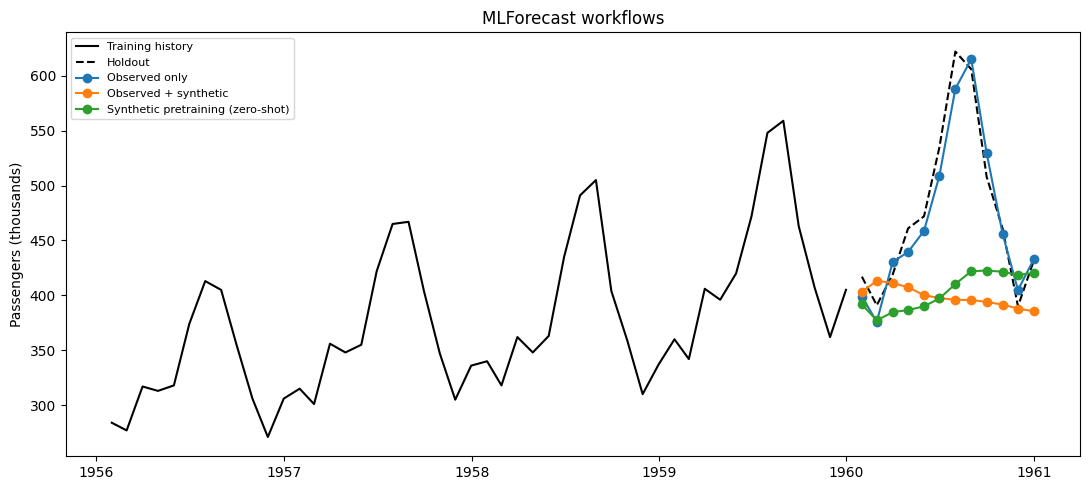

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
history = train_df.tail(48)
ax.plot(history["ds"], history["y"], color="black", label="Training history")
ax.plot(test_df["ds"], test_df["y"], color="black", linestyle="--", label="Holdout")
for label in forecast_sets:
    ax.plot(comparison["ds"], comparison[label], marker="o", label=label)
ax.set(title="MLForecast workflows", ylabel="Passengers (thousands)")
ax.legend(fontsize=8)
fig.tight_layout()

Treat the table as a workflow demonstration rather than evidence that augmentation always improves accuracy. Evaluate multiple temporal folds, generator configurations, estimators, and random seeds for the production decision.